Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Define the output directory for visualizations

In [2]:
output_visualization_dir = "/home/krishantha/Github/fyp-l4/data/visualizations"
os.makedirs(output_visualization_dir, exist_ok=True)  # Create if it doesn't exist


Load the processed data

In [3]:
csv_filepath = "/home/krishantha/Github/fyp-l4/data/processed_data/user_post_data.csv"

try:
    final_df = pd.read_csv(csv_filepath)
    print("Data loaded successfully!")
except FileNotFoundError:
    print(f"Error: CSV file not found at {csv_filepath}")
    # Handle the error appropriately, maybe stop execution or provide an alternative
    # For this example, we'll just exit
    exit()

Data loaded successfully!


Convert 'timestamp' to datetime objects for time-based analysis

In [4]:
final_df['datetime'] = pd.to_datetime(final_df['timestamp'], unit='s')
final_df['day_of_week'] = final_df['datetime'].dt.dayofweek #0 - Monday , 6 - Sunday
final_df['hour_of_day'] = final_df['datetime'].dt.hour


# --- Visualizations ---

# 1. Distribution of Likes and Comments:

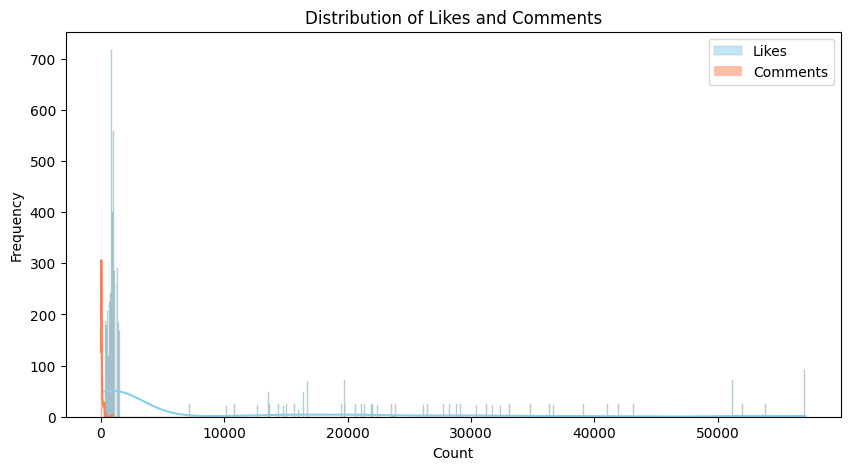

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(final_df['likes'], kde=True, label='Likes', color='skyblue')
sns.histplot(final_df['comments_count'], kde=True, label='Comments', color='coral')
plt.title('Distribution of Likes and Comments')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.legend()
plt.savefig(os.path.join(output_visualization_dir, "likes_comments_distribution.png"))
plt.show()

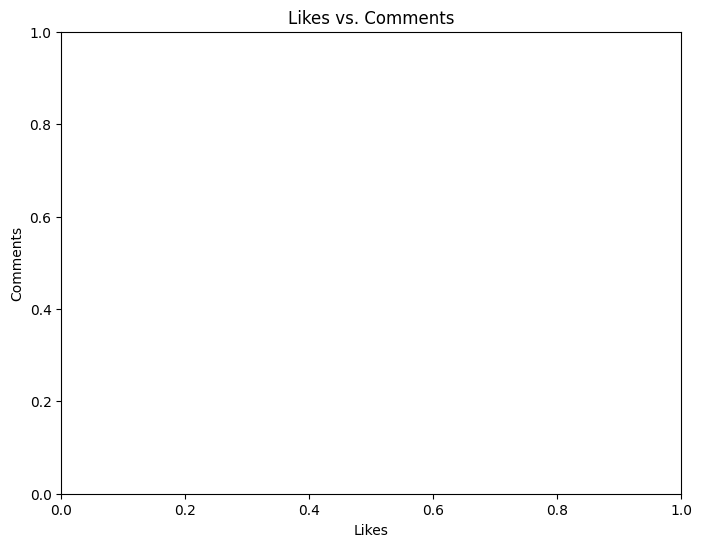

In [6]:
# 2. Likes vs. Comments Scatter Plot:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='likes', y='comments_count', data=final_df, hue='Category', alpha=0.5)
plt.title('Likes vs. Comments')
plt.xlabel('Likes')
plt.ylabel('Comments')
plt.savefig(os.path.join(output_visualization_dir, "likes_vs_comments.png"))
plt.show()

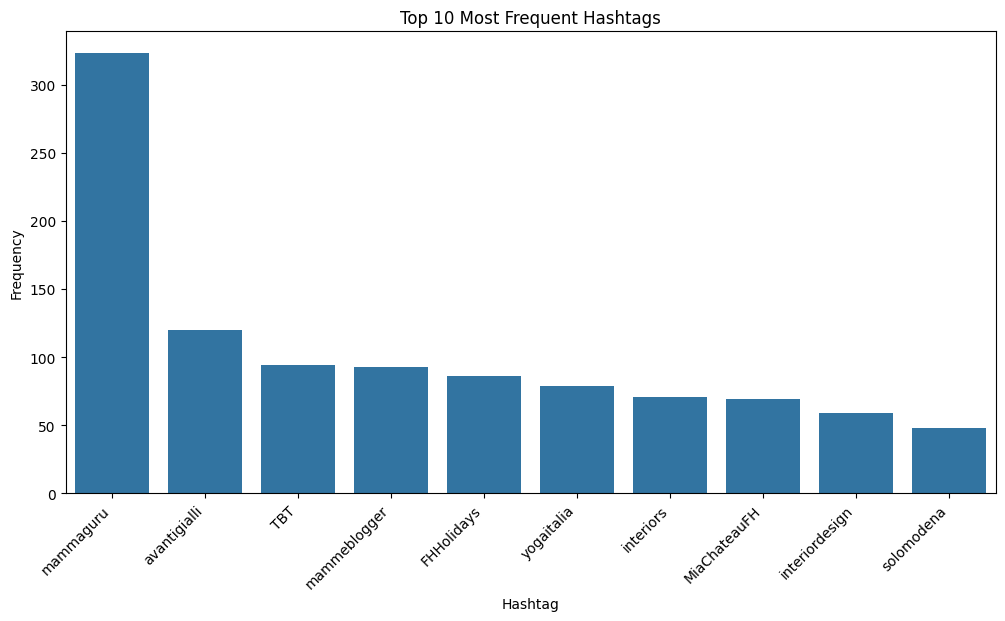

In [7]:

# 3. Top Hashtags:
top_hashtags = final_df['hashtags'].value_counts().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_hashtags.index, y=top_hashtags.values)
plt.title('Top 10 Most Frequent Hashtags')
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(output_visualization_dir, "top_hashtags.png"))
plt.show()



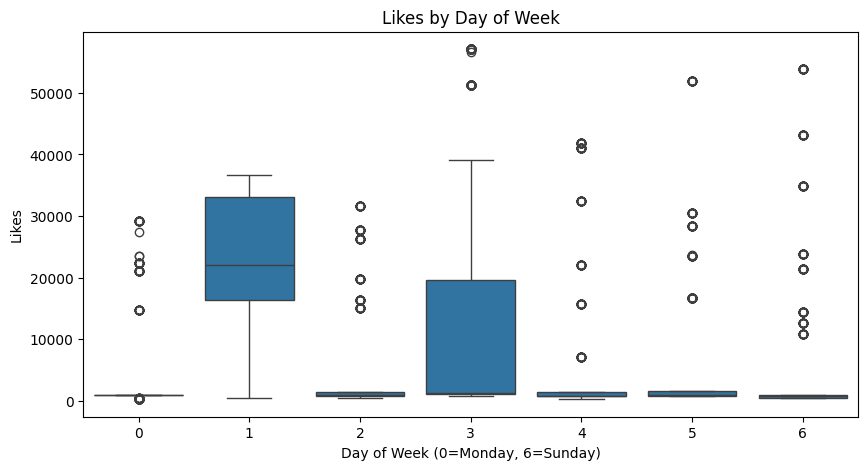

In [8]:

# 4. Engagement Over Time:
# Example: Likes by Day of Week
plt.figure(figsize=(10, 5))
sns.boxplot(x='day_of_week', y='likes', data=final_df)  # No need to create 'day_of_week' again
plt.title('Likes by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Likes')
plt.savefig(os.path.join(output_visualization_dir, "likes_by_day.png"))
plt.show()


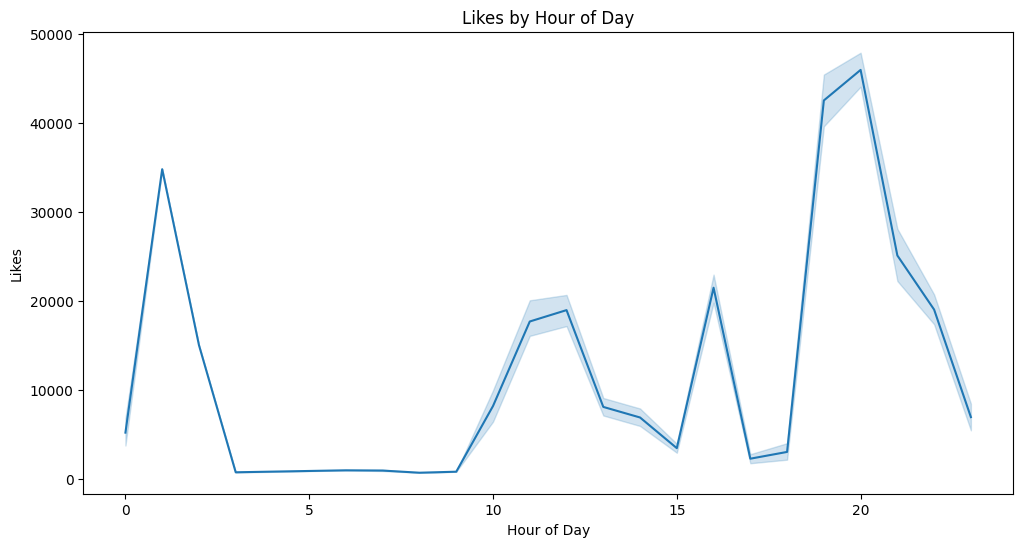

In [9]:
# Example: Likes by Hour of Day
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour_of_day', y='likes', data=final_df) #No need to create 'hour_of_day' column again.
plt.title('Likes by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Likes')
plt.savefig(os.path.join(output_visualization_dir, "likes_by_hour.png"))
plt.show()

ValueError: List of boxplot statistics and `positions` values must have same the length

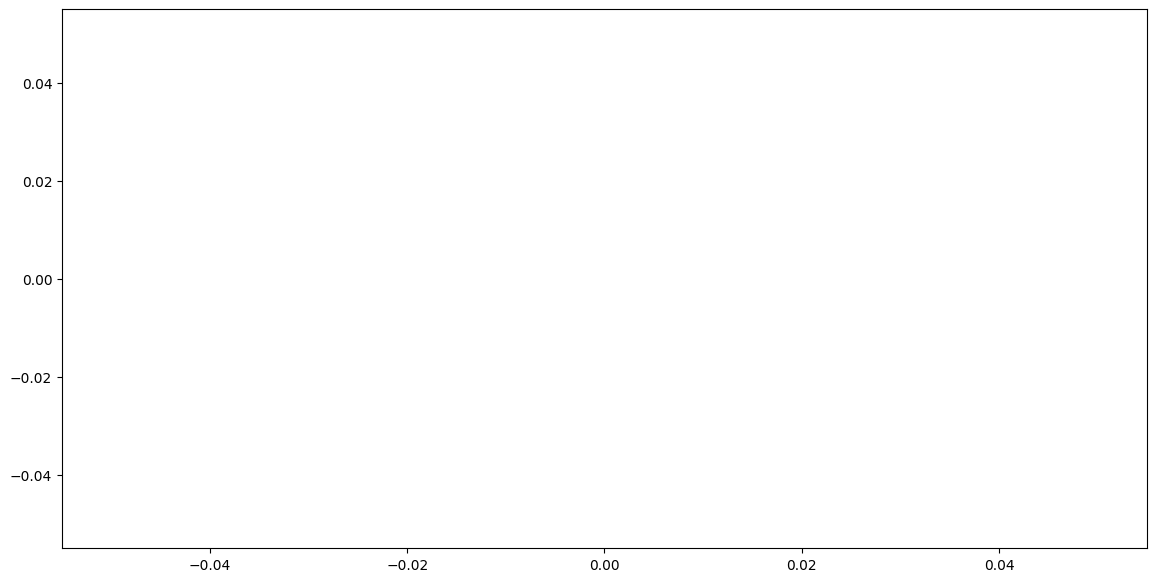

In [10]:
# 5. Category-Specific Analysis:
# Example - Distribution of likes for each category
plt.figure(figsize=(14, 7))
sns.boxplot(x='Category', y='likes', data=final_df)
plt.title('Distribution of Likes by Category')
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(output_visualization_dir, "likes_by_category.png"))
plt.show()


In [ ]:
print(f"Visualizations saved to {output_visualization_dir}")